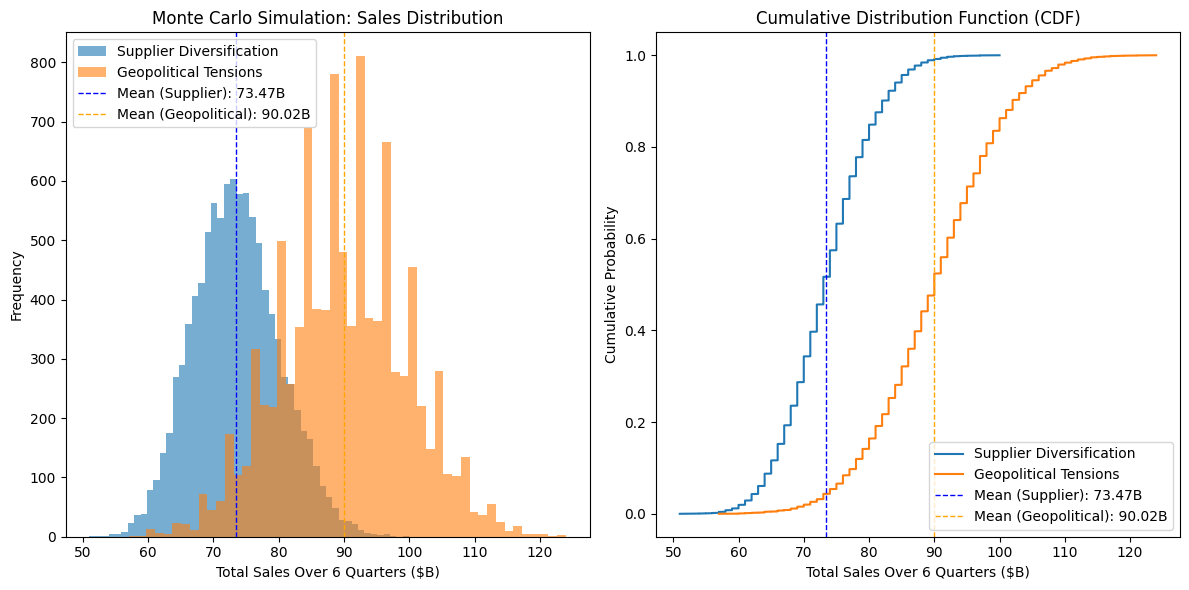

,Risk Type,Mean Sales ($B),Standard Deviation ($B),Min Sales ($B),Max Sales ($B),25th Percentile ($B),Median Sales ($B),75th Percentile ($B)
0,Supplier Diversification,73.4705,6.726881,51,100,69.0,73.0,78.0
1,Geopolitical Tensions,90.0183,9.638753,57,124,83.0,90.0,97.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define sales data from the updated scenario tree
supplier_diversification_sales = {
    "Poor": [8, 9, 10],
    "Sufficient": [11, 12, 13],
    "Excellent": [14, 16, 18]
}

geopolitical_tensions_sales = {
    "Intense": [8, 10, 12],
    "Moderate": [13, 15, 17],
    "Calm": [18, 20, 22]
}

# Monte Carlo simulation parameters
simulations = 10000
quarters = 6

# Function to perform Monte Carlo simulation for sales scenarios
def monte_carlo_simulation(sales_scenarios):
    results = []
    for _ in range(simulations):
        total_sales = 0
        for _ in range(quarters):
            scenario = np.random.choice(list(sales_scenarios.keys()), p=[0.25, 0.50, 0.25])
            sales = np.random.choice(sales_scenarios[scenario])
            total_sales += sales
        results.append(total_sales)
    return results

# Run simulations for both risk factors
supplier_results = monte_carlo_simulation(supplier_diversification_sales)
geopolitical_results = monte_carlo_simulation(geopolitical_tensions_sales)

# Calculate mean values for the mean lines
supplier_mean = np.mean(supplier_results)
geopolitical_mean = np.mean(geopolitical_results)

# Plot histograms and CDF with mean lines
plt.figure(figsize=(12, 6))

# Histogram plot
plt.subplot(1, 2, 1)
plt.hist(supplier_results, bins=50, alpha=0.6, label='Supplier Diversification')
plt.hist(geopolitical_results, bins=50, alpha=0.6, label='Geopolitical Tensions')
plt.axvline(supplier_mean, color='blue', linestyle='dashed', linewidth=1, label=f'Mean (Supplier): {supplier_mean:.2f}B')
plt.axvline(geopolitical_mean, color='orange', linestyle='dashed', linewidth=1, label=f'Mean (Geopolitical): {geopolitical_mean:.2f}B')
plt.xlabel('Total Sales Over 6 Quarters ($B)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation: Sales Distribution')
plt.legend()

# CDF plot
plt.subplot(1, 2, 2)
supplier_sorted = np.sort(supplier_results)
geopolitical_sorted = np.sort(geopolitical_results)
plt.plot(supplier_sorted, np.linspace(0, 1, len(supplier_sorted)), label='Supplier Diversification')
plt.plot(geopolitical_sorted, np.linspace(0, 1, len(geopolitical_sorted)), label='Geopolitical Tensions')
plt.axvline(supplier_mean, color='blue', linestyle='dashed', linewidth=1, label=f'Mean (Supplier): {supplier_mean:.2f}B')
plt.axvline(geopolitical_mean, color='orange', linestyle='dashed', linewidth=1, label=f'Mean (Geopolitical): {geopolitical_mean:.2f}B')
plt.xlabel('Total Sales Over 6 Quarters ($B)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF)')
plt.legend()

plt.tight_layout()
plt.show()

# Prepare summary results in a dataframe for each simulation
summary_data = {
    "Risk Type": ["Supplier Diversification", "Geopolitical Tensions"],
    "Mean Sales ($B)": [supplier_mean, geopolitical_mean],
    "Standard Deviation ($B)": [np.std(supplier_results), np.std(geopolitical_results)],
    "Min Sales ($B)": [np.min(supplier_results), np.min(geopolitical_results)],
    "Max Sales ($B)": [np.max(supplier_results), np.max(geopolitical_results)],
    "25th Percentile ($B)": [np.percentile(supplier_results, 25), np.percentile(geopolitical_results, 25)],
    "Median Sales ($B)": [np.median(supplier_results), np.median(geopolitical_results)],
    "75th Percentile ($B)": [np.percentile(supplier_results, 75), np.percentile(geopolitical_results, 75)]
}

summary_df = pd.DataFrame(summary_data)
summary_df

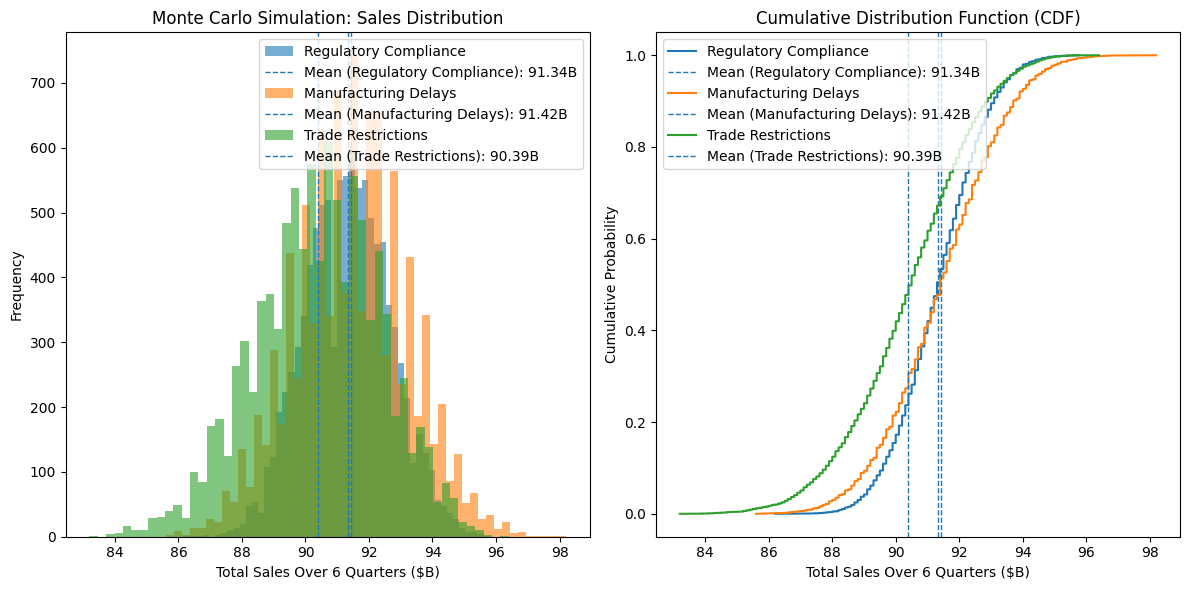

               Risk Type  Mean Sales ($B)  Standard Deviation ($B)  \
0  Regulatory Compliance         91.33957                 1.348663   
1   Manufacturing Delays         91.42367                 1.797856   
2     Trade Restrictions         90.39180                 1.967355   

   Min Sales ($B)  Max Sales ($B)  25th Percentile ($B)  Median Sales ($B)  \
0            86.2            95.8                  90.4               91.3   
1            85.6            98.2                  90.2               91.4   
2            83.2            96.4                  89.1               90.5   

   75th Percentile ($B)  
0                  92.3  
1                  92.7  
2                  91.8  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define sales data from the updated scenario tree
sales_scenarios = {
    "Regulatory Compliance": {
        "Calm": [15.8, 16.0, 16.2],
        "Moderate": [15.0, 15.2, 15.4],
        "Intense": [14.3, 14.5, 14.7]
    },
    "Manufacturing Delays": {
        "Calm": [16.0, 16.2, 16.5],
        "Moderate": [15.0, 15.2, 15.5],
        "Intense": [14.0, 14.2, 14.5]
    },
    "Trade Restrictions": {
        "Calm": [15.9, 16.0, 16.2],
        "Moderate": [15.0, 15.2, 15.4],
        "Intense": [13.7, 13.8, 14.0]
    }
}

# Monte Carlo simulation parameters
simulations = 10000
quarters = 6

# Function to perform Monte Carlo simulation for sales scenarios
def monte_carlo_simulation(sales_data):
    results = []
    for _ in range(simulations):
        total_sales = 0
        for _ in range(quarters):
            scenario = np.random.choice(["Calm", "Moderate", "Intense"], p=[0.25, 0.50, 0.25])
            sales = np.random.choice(sales_data[scenario])
            total_sales += sales
        results.append(total_sales)
    return results

# Run simulations for all three risk factors
simulation_results = {key: monte_carlo_simulation(value) for key, value in sales_scenarios.items()}

# Compute mean values
mean_values = {key: np.mean(value) for key, value in simulation_results.items()}

# Plot histograms and CDF with mean lines
plt.figure(figsize=(12, 6))

# Histogram plot
plt.subplot(1, 2, 1)
for key, values in simulation_results.items():
    plt.hist(values, bins=50, alpha=0.6, label=key)
    plt.axvline(np.mean(values), linestyle='dashed', linewidth=1, label=f'Mean ({key}): {np.mean(values):.2f}B')

plt.xlabel('Total Sales Over 6 Quarters ($B)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation: Sales Distribution')
plt.legend()

# CDF plot
plt.subplot(1, 2, 2)
for key, values in simulation_results.items():
    sorted_values = np.sort(values)
    plt.plot(sorted_values, np.linspace(0, 1, len(sorted_values)), label=key)
    plt.axvline(np.mean(values), linestyle='dashed', linewidth=1, label=f'Mean ({key}): {np.mean(values):.2f}B')

plt.xlabel('Total Sales Over 6 Quarters ($B)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function (CDF)')
plt.legend()

plt.tight_layout()
plt.show()

# Prepare summary results in a dataframe
summary_data = {
    "Risk Type": list(simulation_results.keys()),
    "Mean Sales ($B)": [np.mean(values) for values in simulation_results.values()],
    "Standard Deviation ($B)": [np.std(values) for values in simulation_results.values()],
    "Min Sales ($B)": [np.min(values) for values in simulation_results.values()],
    "Max Sales ($B)": [np.max(values) for values in simulation_results.values()],
    "25th Percentile ($B)": [np.percentile(values, 25) for values in simulation_results.values()],
    "Median Sales ($B)": [np.median(values) for values in simulation_results.values()],
    "75th Percentile ($B)": [np.percentile(values, 75) for values in simulation_results.values()]
}

summary_df = pd.DataFrame(summary_data)

# Display summary results
print(summary_df)